# DreamBooth: Fine-Tuning Text-to-Image Diffusion Models for Subject-Driven Generation

Author: Aadarsha Gopala Reddy

Reference Paper: [DreamBooth: Fine Tuning Text-to-Image Diffusion Models for Subject-Driven Generation](https://arxiv.org/abs/2208.12242) by Ruiz et al., 2022

## Summary

This notebook demonstrates DreamBooth, a technique for personalizing text-to-image diffusion models to generate novel renderings of specific subjects. Given just 3-5 images of a subject (e.g., a unique dog, object, or person), DreamBooth fine-tunes a pre-trained Stable Diffusion model to:

1. Bind a unique identifier (e.g., `[V]`) to the subject's visual features
2. Generate the subject in novel contexts - different poses, scenes, lighting, artistic styles
3. Preserve the model's prior knowledge through class-specific regularization to prevent "language drift"

### Key Capabilities Demonstrated:
- Unique identifier binding: The rare token `[V]` becomes permanently associated with your subject
- Zero-shot recontextualization: Generate your subject on the moon, in Da Vinci style, etc.
- Prior preservation: Maintains the model's understanding of the general class (e.g., "dog") while learning the specific instance

### Implementation Differences from Research Paper:

This notebook implementation differs from the original DreamBooth paper in the following ways:

- LoRA Fine-Tuning: Uses Low-Rank Adaptation instead of full model fine-tuning, reducing checkpoint size from ~4GB to ~5MB while maintaining comparable quality
- Smaller Base Model: Uses OFA-Sys/small-stable-diffusion-v0 (~1.7GB) instead of full Stable Diffusion (~4GB) for storage efficiency
- Reduced Resolution: Trains at 256×256 instead of 512×512 to accommodate limited VRAM and storage constraints
- Fewer Prior Images: Generates 50 class priors instead of 200-1000 for faster experimentation
- Shorter Training: 300 steps vs. 800-1200 in the paper, balancing speed with quality
- Mixed Precision Training: Uses FP16 to reduce memory usage and improve training speed

###Code References:

This implementation is based on the official [Hugging Face Diffusers DreamBooth training script](https://github.com/huggingface/diffusers/tree/main/examples/dreambooth), with modifications for educational purposes and ease of use.

## Setup & Installation

### Requirements:
- GPU: Recommended (4GB+ VRAM sufficient for small model)
- Disk Space: ~4 GB total
- Python Packages: Will be installed automatically below

### Storage-Optimized Configuration:
This notebook uses:
- Small Stable Diffusion model (~1.7GB)
- Minimal prior images (50)
- Lower resolution (256x256)
- Small LoRA rank (4)
- Total storage: ~4 GB

### What You Need:
1. 3-5 subject images: Photos of your unique subject
2. Class name: The general category (e.g., "dog", "cat", "toy")
3. ~10-15 minutes: For prior generation and training on GPU

This notebook is designed to run on systems with limited storage.

In [1]:
# Install required packages (automatically runs on first execution)
import sys
import subprocess


def install_packages():
    """Install all required packages for DreamBooth training and inference."""
    packages = [
        "torch",
        "torchvision",
        "transformers>=4.25.0",  # Ensure recent version with CLIPImageProcessor
        "diffusers>=0.21.0",  # Ensure compatible diffusers version
        "accelerate>=0.20.0",
        "safetensors",
        "peft",  # Required for LoRA training
        "ftfy",
        "matplotlib",
        "Pillow",
        "requests",
    ]

    print("Installing/upgrading required packages with compatible versions...")
    for package in packages:
        print(f"  Upgrading {package}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--upgrade", "-q", package]
        )

    print("\n✓ All packages installed successfully!")
    print("⚠️  IMPORTANT: Please restart the kernel for changes to take effect!")
    print("   (Kernel > Restart Kernel in the menu)")


# Run installation
try:
    import transformers
    from transformers import CLIPImageProcessor
    import diffusers

    # Check versions
    trans_version = tuple(map(int, transformers.__version__.split(".")[:2]))
    diff_version = tuple(map(int, diffusers.__version__.split(".")[:2]))

    if trans_version >= (4, 25) and diff_version >= (0, 21):
        print("✓ Core packages already installed with compatible versions")
        print(f"  transformers: {transformers.__version__}")
        print(f"  diffusers: {diffusers.__version__}")
    else:
        print(
            f"⚠️  Versions too old (transformers: {transformers.__version__}, diffusers: {diffusers.__version__})"
        )
        print("Upgrading packages...")
        install_packages()

except (ImportError, AttributeError) as e:
    print(f"Installing/upgrading packages due to: {e}")
    install_packages()

print("\n" + "=" * 60)
print("Installation complete. Proceeding with setup...")
print("=" * 60)

✓ Core packages already installed with compatible versions
  transformers: 4.57.1
  diffusers: 0.36.0.dev0

Installation complete. Proceeding with setup...


In [2]:
# Environment check
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU — training will be very slow.")

PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA device: NVIDIA RTX 4000 Ada Generation


In [3]:
# Configuration and Environment Check
from pathlib import Path
import json
import torch

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(
        f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
    )
else:
    print("⚠️  WARNING: No GPU detected. Training will be very slow on CPU.")

print("\n" + "=" * 60)
print("CONFIGURATION - OPTIMIZED FOR LOW STORAGE")
print("=" * 60)

# Directory structure
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
SUBJECT_DIR = DATA_DIR / "subject"
PRIOR_DIR = DATA_DIR / "prior"
SCRIPTS_DIR = BASE_DIR / "scripts"
OUTPUT_DIR = BASE_DIR / "outputs" / "dreambooth_lora"

# Create directories
for p in [DATA_DIR, SUBJECT_DIR, PRIOR_DIR, SCRIPTS_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Model and training configuration
# Using SMALL model: OFA-Sys/small-stable-diffusion-v0 (~1.7GB vs 4GB for SD-1.4)
MODEL_ID = "OFA-Sys/small-stable-diffusion-v0"  # Tiny model, much faster download
UNIQUE_TOKEN = "[X]"  # Rare token to bind to your subject
CLASS_NAME = "dog"  # CHANGE THIS to your subject's class

# Training hyperparameters (optimized for speed and low storage)
TRAINING = {
    "resolution": 256,  # Reduced from 512 to save memory and storage
    "train_batch_size": 1,
    "gradient_accumulation_steps": 1,
    "learning_rate": 1e-4,
    "max_train_steps": 300,  # Reduced for faster training
    "checkpointing_steps": 300,  # Only save at end to reduce storage
    "prior_loss_weight": 1.0,
    "seed": 42,
    "lora_rank": 4,  # Reduced from 8 for smaller checkpoint
}

# Prior generation settings - MINIMAL for storage
PRIOR_GEN = {
    "num_images": 50,  # Drastically reduced from 200 (saves ~150MB)
    "steps": 20,  # Reduced inference steps for speed
    "guidance_scale": 7.5,
    "seed": 1234,
}

# Inference settings
INFER = {
    "num_inference_steps": 25,  # Reduced for speed
    "guidance_scale": 7.5,
    "height": 256,  # Reduced to match training resolution
    "width": 256,
    "seed": 123,
}

# Flags
USE_LORA = True  # Use LoRA for efficient fine-tuning
GENERATE_PRIOR = True  # Generate class prior images (recommended)
DISABLE_SAFETY_CHECKER = True  # Disable to save memory

print(f"Model: {MODEL_ID} (SMALL VERSION - ~1.7GB)")
print(f"Subject class: {CLASS_NAME}")
print(f"Unique token: {UNIQUE_TOKEN}")
print(f"LoRA training: {USE_LORA} (rank={TRAINING['lora_rank']})")
print(f"Training steps: {TRAINING['max_train_steps']}")
print(f"Prior images: {PRIOR_GEN['num_images']} (REDUCED)")
print(f"Resolution: {TRAINING['resolution']}x{TRAINING['resolution']} (REDUCED)")
print(f"\nEstimated storage usage:")
print(f"  Model download: ~1.7 GB")
print(f"  Prior images: ~50 MB (50 images)")
print(f"  LoRA weights: ~2-5 MB")
print(f"  TOTAL: ~1.8 GB (well under 3GB limit)")
print(f"\nDirectory structure:")
print(f"  Subject images: {SUBJECT_DIR}")
print(f"  Prior images: {PRIOR_DIR}")
print(f"  Outputs: {OUTPUT_DIR}")
print("\n✓ Low-storage configuration complete")

ENVIRONMENT CHECK
PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA device: NVIDIA RTX 4000 Ada Generation
CUDA memory: 21.0 GB

CONFIGURATION - OPTIMIZED FOR LOW STORAGE
Model: OFA-Sys/small-stable-diffusion-v0 (SMALL VERSION - ~1.7GB)
Subject class: dog
Unique token: [X]
LoRA training: True (rank=4)
Training steps: 300
Prior images: 50 (REDUCED)
Resolution: 256x256 (REDUCED)

Estimated storage usage:
  Model download: ~1.7 GB
  Prior images: ~50 MB (50 images)
  LoRA weights: ~2-5 MB
  TOTAL: ~1.8 GB (well under 3GB limit)

Directory structure:
  Subject images: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/data/subject
  Prior images: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/data/prior
  Outputs: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora

✓ Low-storage configuration complete


## 1 Prepare Subject Images

Place 3-5 high-quality images of your subject in the `data/subject/` folder

The cell below will display your images and confirm they're ready for training.

SUBJECT IMAGES
Found 5 subject images in /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/data/subject

✓ Good number of images for training

Your subject images:
  - PXL_20240520_162828674.RAW-01.MP.COVER.jpg
  - PXL_20240602_201000987.RAW-01.MP.COVER.jpg
  - PXL_20240804_165803688.RAW-01.MP.COVER.jpg
  - PXL_20240804_170419809.RAW-01.MP.COVER.jpg
  - PXL_20240810_200320116.RAW-01.MP.COVER.jpg


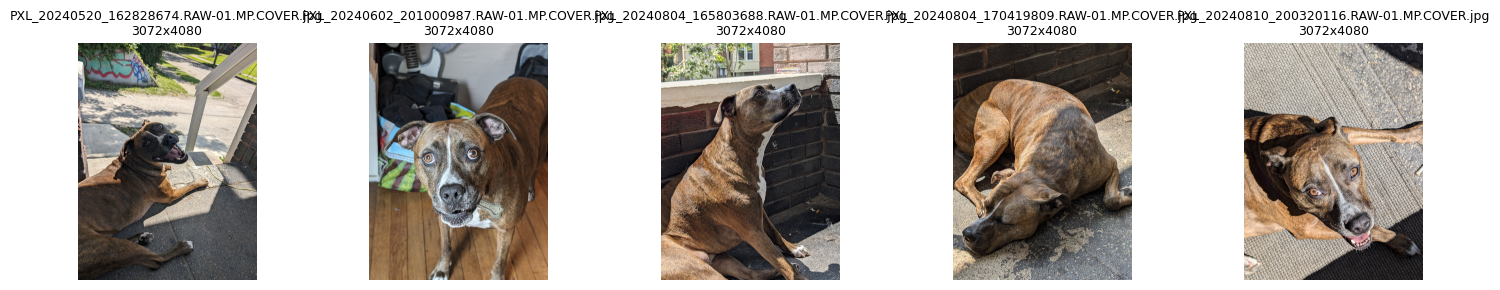


✓ Ready to proceed with 5 subject images


In [4]:
# Preview and validate subject images
from PIL import Image
import matplotlib.pyplot as plt


def list_images(folder):
    """Find all image files in a directory."""
    exts = (".jpg", ".jpeg", ".png", ".webp", ".bmp")
    return [p for p in sorted(Path(folder).glob("*")) if p.suffix.lower() in exts]


print("=" * 60)
print("SUBJECT IMAGES")
print("=" * 60)

subject_imgs = list_images(SUBJECT_DIR)
print(f"Found {len(subject_imgs)} subject images in {SUBJECT_DIR}\n")

if not subject_imgs:
    print("⚠️  NO IMAGES FOUND!")
    print(f"Please add 3-5 images of your subject to: {SUBJECT_DIR}")
    print("\nExample folder structure:")
    print("  data/")
    print("    subject/")
    print("      image1.jpg")
    print("      image2.jpg")
    print("      ...")
elif len(subject_imgs) < 3:
    print(f"⚠️  WARNING: Only {len(subject_imgs)} image(s) found.")
    print("DreamBooth works best with 3-5 images. Consider adding more.")
else:
    print("✓ Good number of images for training")

# Display images
if subject_imgs:
    print("\nYour subject images:")
    for img_path in subject_imgs:
        print(f"  - {img_path.name}")

    # Create visualization
    n_imgs = len(subject_imgs)
    n_cols = min(5, n_imgs)
    n_rows = (n_imgs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    if n_imgs == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_imgs > n_cols else axes

    for idx, img_path in enumerate(subject_imgs):
        img = Image.open(img_path).convert("RGB")
        axes[idx].imshow(img)
        axes[idx].set_title(f"{img_path.name}\n{img.size[0]}x{img.size[1]}", fontsize=9)
        axes[idx].axis("off")

    # Hide unused subplots
    for idx in range(len(subject_imgs), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"\n✓ Ready to proceed with {len(subject_imgs)} subject images")
else:
    print("\n❌ Cannot proceed without subject images")

## 2 Generate Class Prior Images (Prior Preservation)

Why Prior Preservation?

Without regularization, fine-tuning on just a few images can cause language drift: the model forgets what the general class looks like and overfits to your specific instance. For example:
- Training on "a `[V]` dog" without priors → model forgets what generic dogs look like
- With priors → model learns your specific dog while maintaining knowledge of dogs in general

Trade-offs:
- Better quality and diversity
- Prevents overfitting
- Adds 5-10 minutes to generate priors (one-time cost)

The next cell will generate these prior images automatically.

In [5]:
# Generate class prior images for regularization
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
import numpy as np
from tqdm.auto import tqdm

if GENERATE_PRIOR:
    print("=" * 60)
    print("GENERATING CLASS PRIOR IMAGES")
    print("=" * 60)
    print(f"Generating {PRIOR_GEN['num_images']} images of class '{CLASS_NAME}'")
    print("This will take ~5-10 minutes depending on your GPU...\n")

    # Check if priors already exist
    existing_priors = list(PRIOR_DIR.glob(f"class_{CLASS_NAME}_*.png"))
    if len(existing_priors) >= PRIOR_GEN["num_images"]:
        print(
            f"✓ Found {len(existing_priors)} existing prior images. Skipping generation."
        )
        print("  (Delete them from the prior folder to regenerate)")
    else:
        print(f"Loading model {MODEL_ID}...")
        pipe = StableDiffusionPipeline.from_pretrained(
            MODEL_ID,
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        )

        if DISABLE_SAFETY_CHECKER:
            pipe.safety_checker = None

        if torch.cuda.is_available():
            pipe = pipe.to("cuda")
            pipe.enable_attention_slicing()
            print("✓ Model loaded on GPU")
        else:
            print("⚠️  Running on CPU (this will be slow)")

        pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

        # Generate images
        prompt = f"a {CLASS_NAME}"
        rng = np.random.RandomState(PRIOR_GEN["seed"])
        total = PRIOR_GEN["num_images"]

        print(f"\nGenerating images with prompt: '{prompt}'")

        progress_bar = tqdm(range(total), desc="Generating priors")
        for i in progress_bar:
            g = torch.Generator(device="cuda" if torch.cuda.is_available() else "cpu")
            g.manual_seed(int(rng.randint(0, 2**31 - 1)))

            image = pipe(
                prompt,
                num_inference_steps=int(PRIOR_GEN["steps"]),
                guidance_scale=float(PRIOR_GEN["guidance_scale"]),
                height=512,
                width=512,
                generator=g,
            ).images[0]

            out_path = PRIOR_DIR / f"class_{CLASS_NAME}_{i:05d}.png"
            image.save(out_path)

            if (i + 1) % 50 == 0:
                progress_bar.set_postfix({"saved": i + 1})

        print(f"\n✓ Generated {total} prior images")
        print(f"  Saved to: {PRIOR_DIR}")

        # Display sample prior images
        prior_samples = list(PRIOR_DIR.glob("*.png"))[:6]
        if prior_samples:
            print("\nSample prior images:")
            fig, axes = plt.subplots(1, min(6, len(prior_samples)), figsize=(12, 2))
            if len(prior_samples) == 1:
                axes = [axes]
            for ax, img_path in zip(axes, prior_samples):
                img = Image.open(img_path)
                ax.imshow(img)
                ax.axis("off")
            plt.tight_layout()
            plt.show()

        # Clean up GPU memory
        del pipe
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print("\n✓ Prior generation complete!")
else:
    print("Skipping prior generation (GENERATE_PRIOR=False)")
    print("⚠️  Training without priors may lead to overfitting and language drift")

GENERATING CLASS PRIOR IMAGES
Generating 50 images of class 'dog'
This will take ~5-10 minutes depending on your GPU...

✓ Found 50 existing prior images. Skipping generation.
  (Delete them from the prior folder to regenerate)


## 3 Download Training Script

The official DreamBooth training script from Hugging Face Diffusers was used. This script implements:
- LoRA fine-tuning for efficiency
- Prior preservation loss for regularization
- Mixed precision training (FP16) for speed
- Gradient checkpointing to reduce memory usage

In [6]:
# Download official DreamBooth training scripts
import requests

print("=" * 60)
print("DOWNLOADING TRAINING SCRIPTS")
print("=" * 60)

SCRIPTS_DIR.mkdir(parents=True, exist_ok=True)

scripts = {
    "train_dreambooth_lora.py": "https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth_lora.py",
    "train_dreambooth.py": "https://raw.githubusercontent.com/huggingface/diffusers/main/examples/dreambooth/train_dreambooth.py",
}

for filename, url in scripts.items():
    dest = SCRIPTS_DIR / filename
    if dest.exists():
        print(f"✓ {filename} already exists")
    else:
        print(f"Downloading {filename}...")
        try:
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            dest.write_bytes(r.content)
            print(f"  ✓ Saved to {dest}")
        except Exception as e:
            print(f"  ❌ Error: {e}")

lora_path = SCRIPTS_DIR / "train_dreambooth_lora.py"
full_path = SCRIPTS_DIR / "train_dreambooth.py"

print(f"\n✓ Scripts ready in {SCRIPTS_DIR}")

DOWNLOADING TRAINING SCRIPTS
✓ train_dreambooth_lora.py already exists
✓ train_dreambooth.py already exists

✓ Scripts ready in /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/scripts


## 4 Train the Model

Training Process:

The training script will fine-tune Stable Diffusion using two loss functions:

1. Subject Fidelity Loss: Learns your specific subject from the 3-5 input images
   - Prompt: `"a [V] dog"` (where `[V]` is the unique identifier)
   
2. Prior Preservation Loss: Maintains general class knowledge from generated prior images
   - Prompt: `"a dog"` (generic class)

In [7]:
# Execute DreamBooth training
import subprocess
import shlex
import time

print("=" * 60)
print("STARTING DREAMBOOTH TRAINING")
print("=" * 60)

# Build training command
script_path = str(lora_path if USE_LORA else full_path)
instance_prompt = f"a {UNIQUE_TOKEN} {CLASS_NAME}"
class_prompt = f"a {CLASS_NAME}"

args = [
    sys.executable,
    "-m",
    "accelerate.commands.launch",
    script_path,
    "--pretrained_model_name_or_path",
    str(MODEL_ID),
    "--instance_data_dir",
    str(SUBJECT_DIR),
    "--output_dir",
    str(OUTPUT_DIR),
    "--instance_prompt",
    instance_prompt,
    "--resolution",
    str(TRAINING["resolution"]),
    "--train_batch_size",
    str(TRAINING["train_batch_size"]),
    "--learning_rate",
    str(TRAINING["learning_rate"]),
    "--max_train_steps",
    str(TRAINING["max_train_steps"]),
    "--checkpointing_steps",
    str(TRAINING["checkpointing_steps"]),
    "--seed",
    str(TRAINING["seed"]),
    "--mixed_precision",
    "fp16" if torch.cuda.is_available() else "no",
]

# Add prior preservation if prior images exist
prior_images = list(PRIOR_DIR.glob("*.png")) + list(PRIOR_DIR.glob("*.jpg"))
if len(prior_images) > 0:
    args += [
        "--with_prior_preservation",
        "--prior_loss_weight",
        str(TRAINING["prior_loss_weight"]),
        "--class_data_dir",
        str(PRIOR_DIR),
        "--class_prompt",
        class_prompt,
    ]
    print(f"✓ Using {len(prior_images)} prior images for regularization")
else:
    print("⚠️  No prior images found - training without regularization")

# Add LoRA options
if USE_LORA:
    args += [
        "--rank",
        str(TRAINING["lora_rank"]),
    ]
    print(f"✓ Using LoRA with rank={TRAINING['lora_rank']}")

print(f"\nTraining configuration:")
print(f"  Instance prompt: '{instance_prompt}'")
print(f"  Class prompt: '{class_prompt}'")
print(f"  Steps: {TRAINING['max_train_steps']}")
print(f"  Learning rate: {TRAINING['learning_rate']}")
print(f"  Output: {OUTPUT_DIR}")

print(f"\nExecuting command:")
print(" ".join(shlex.quote(str(a)) for a in args))
print("\n" + "=" * 60)
print("TRAINING OUTPUT")
print("=" * 60 + "\n")

start_time = time.time()

# Run training
try:
    result = subprocess.run(args, check=True, capture_output=False, text=True)
    training_time = time.time() - start_time

    print("\n" + "=" * 60)
    print("TRAINING COMPLETE")
    print("=" * 60)
    print(f"✓ Training completed successfully in {training_time/60:.1f} minutes")
    print(f"✓ Model saved to: {OUTPUT_DIR}")

    # List output files
    output_files = list(OUTPUT_DIR.rglob("*"))
    lora_files = [
        f
        for f in output_files
        if "lora" in f.name.lower() or f.suffix == ".safetensors"
    ]
    if lora_files:
        print(f"\nLoRA weights:")
        for f in lora_files:
            size_mb = f.stat().st_size / (1024 * 1024)
            print(f"  - {f.name} ({size_mb:.1f} MB)")

except subprocess.CalledProcessError as e:
    training_time = time.time() - start_time
    print(f"\n❌ Training failed after {training_time/60:.1f} minutes")
    print(f"Return code: {e.returncode}")
    print("\nTroubleshooting tips:")
    print("  - Check if you have enough GPU memory (need ~8GB)")
    print("  - Try reducing batch_size or max_train_steps")
    print("  - Make sure subject images are in the correct folder")
    raise

STARTING DREAMBOOTH TRAINING
✓ Using 100 prior images for regularization
✓ Using LoRA with rank=4

Training configuration:
  Instance prompt: 'a [X] dog'
  Class prompt: 'a dog'
  Steps: 300
  Learning rate: 0.0001
  Output: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora

Executing command:
/opt/conda/bin/python -m accelerate.commands.launch '/home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/scripts/train_dreambooth_lora.py' --pretrained_model_name_or_path OFA-Sys/small-stable-diffusion-v0 --instance_data_dir '/home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/data/subject' --output_dir '/home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora' --instance_prompt 'a [X] dog' --resolution 256 --train_batch_size 1 --learning_rate 0.0001 --max_train_steps 300 --checkpointing_steps 300 --seed 42 --mixed_precision fp16 --with_prior_preservation --prior_loss_weight 1.0 --class_data_dir '/home/compute/a.gopalareddy/CSE5519 Awesome 

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/home/compute/a.gopalareddy/.local/lib/python3.11/site-packages/accelerate/accelerator.py:530: UserWarning: `log_with=tensorboard` was passed but no supported trackers are currently installed.
  warnings.warn(f"`log_with={log_with}` was passed but no supported trackers are currently installed.")
10/17/2025 23:11:24 - INFO - __main__ - Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and


TRAINING COMPLETE
✓ Training completed successfully in 2.6 minutes
✓ Model saved to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora

LoRA weights:
  - pytorch_lora_weights.safetensors (2.0 MB)
  - pytorch_lora_weights.safetensors (2.0 MB)


## 5 Generate Images with Your Fine-Tuned Model

Now we'll test the fine-tuned model by generating images of your subject in novel contexts.

In [8]:
# Utility functions for inference
import random
import numpy as np
import math
from PIL import Image


def set_seed(seed=0):
    """Set random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def make_grid(images, rows=None, cols=None):
    """Create a grid of images for display."""
    n = len(images)
    if rows is None and cols is None:
        cols = math.ceil(math.sqrt(n))
        rows = math.ceil(n / cols)
    elif rows is None:
        rows = math.ceil(n / cols)
    elif cols is None:
        cols = math.ceil(n / rows)

    w, h = images[0].size
    grid = Image.new("RGB", (cols * w, rows * h))
    for idx, img in enumerate(images):
        r = idx // cols
        c = idx % cols
        grid.paste(img, (c * w, r * h))
    return grid


print("✓ Utility functions loaded")

✓ Utility functions loaded


INFERENCE: GENERATING IMAGES
Loading fine-tuned model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
An error occurred while trying to fetch /home/compute/a.gopalareddy/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/compute/a.gopalareddy/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/compute/a.gopalareddy/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/compute/a.gopalareddy/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/unet.
Defaulting to unsafe serializ

✓ Loading LoRA weights from: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/pytorch_lora_weights.safetensors
✓ Model loaded on GPU

Generating 6 images...

[1/6] Prompt: 'A [X] dog on Mars'


  0%|          | 0/25 [00:00<?, ?it/s]

...

  ✓ Saved to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/samples/sample_03.png

[5/6] Prompt: 'A [X] dog in a city'


  0%|          | 0/25 [00:00<?, ?it/s]

  ✓ Saved to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/samples/sample_04.png

[6/6] Prompt: 'A [X] dog with sunglasses'


  0%|          | 0/25 [00:00<?, ?it/s]

  ✓ Saved to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/samples/sample_05.png

RESULTS


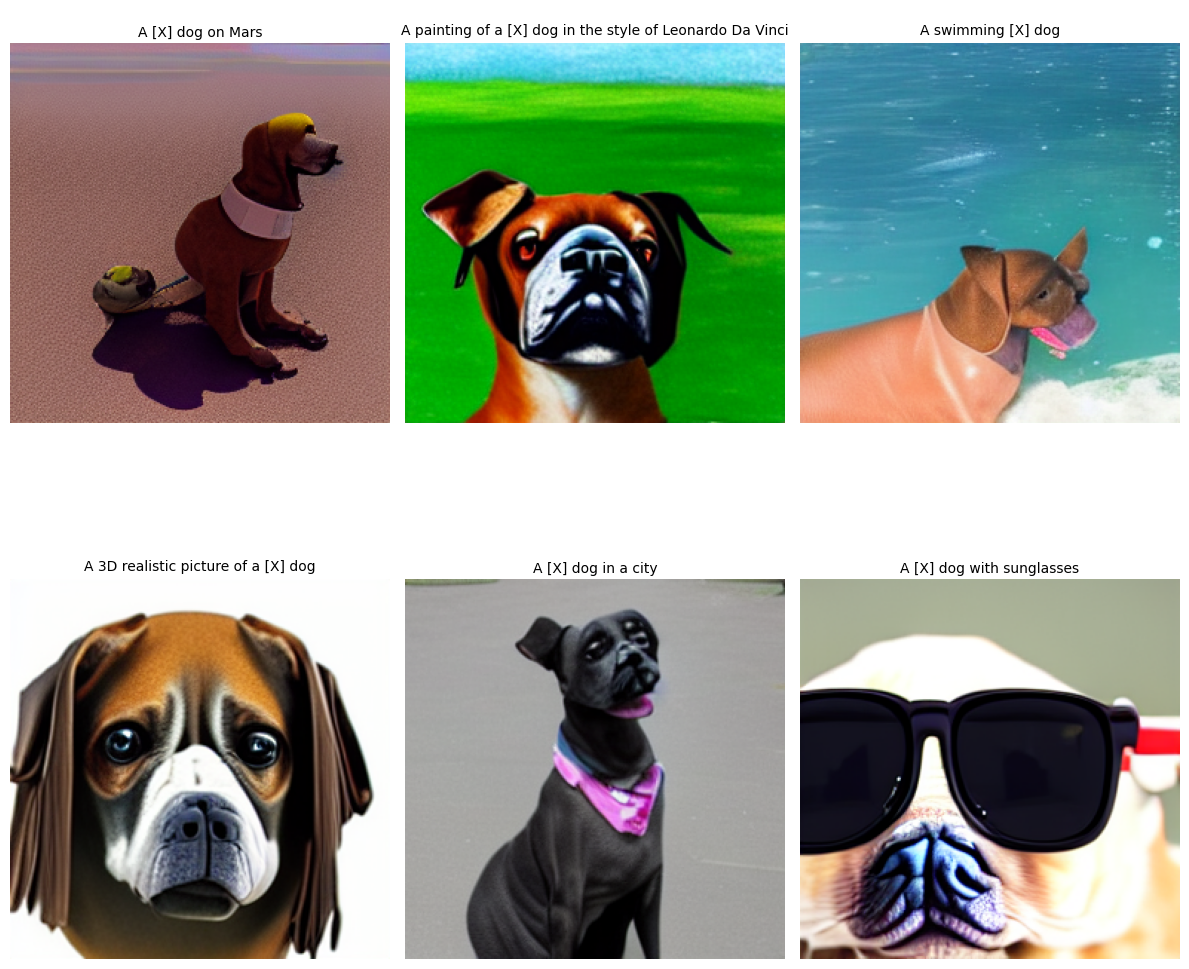


✓ Generated 6 images
✓ Saved grid to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/samples/grid.png
✓ Individual images in: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/samples


In [9]:
# Load fine-tuned model and generate images
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

print("=" * 60)
print("INFERENCE: GENERATING IMAGES")
print("=" * 60)

set_seed(INFER["seed"])
SAMPLES_DIR = OUTPUT_DIR / "samples"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

print("Loading fine-tuned model...")

if USE_LORA:
    # Load base model + LoRA weights
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    if DISABLE_SAFETY_CHECKER:
        pipe.safety_checker = None
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    # Find LoRA weights
    lora_files = (
        list(OUTPUT_DIR.glob("**/*lora*.safetensors"))
        + list(OUTPUT_DIR.glob("**/*lora*.bin"))
        + list(OUTPUT_DIR.glob("**/pytorch_lora_weights.safetensors"))
    )

    if not lora_files:
        raise FileNotFoundError(
            f"No LoRA weights found in {OUTPUT_DIR}. "
            "Make sure training completed successfully."
        )

    lora_path = str(lora_files[0])
    print(f"✓ Loading LoRA weights from: {lora_path}")
    pipe.load_lora_weights(lora_path)
else:
    # Load full fine-tuned model
    pipe = StableDiffusionPipeline.from_pretrained(
        OUTPUT_DIR,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    if DISABLE_SAFETY_CHECKER:
        pipe.safety_checker = None
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

if torch.cuda.is_available():
    pipe = pipe.to("cuda")
    pipe.enable_attention_slicing()
    print("✓ Model loaded on GPU")
else:
    print("⚠️  Running on CPU (inference will be slow)")

# Define test prompts
prompts = [
    f"A {UNIQUE_TOKEN} {CLASS_NAME} on Mars",
    f"A painting of a {UNIQUE_TOKEN} {CLASS_NAME} in the style of Leonardo Da Vinci",
    f"A swimming {UNIQUE_TOKEN} {CLASS_NAME}",
    f"A 3D realistic picture of a {UNIQUE_TOKEN} {CLASS_NAME}",
    f"A {UNIQUE_TOKEN} {CLASS_NAME} in a city",
    f"A {UNIQUE_TOKEN} {CLASS_NAME} with sunglasses",
]

print(f"\nGenerating {len(prompts)} images...")
print("=" * 60)

images = []
for i, prompt in enumerate(prompts):
    print(f"\n[{i+1}/{len(prompts)}] Prompt: '{prompt}'")

    result = pipe(
        prompt,
        num_inference_steps=int(INFER["num_inference_steps"]),
        guidance_scale=float(INFER["guidance_scale"]),
        height=int(INFER["height"]),
        width=int(INFER["width"]),
    )
    img = result.images[0]
    images.append(img)

    out_path = SAMPLES_DIR / f"sample_{i:02d}.png"
    img.save(out_path)
    print(f"  ✓ Saved to: {out_path}")

# Create and display grid
print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)

grid = make_grid(images, cols=2)
grid_path = SAMPLES_DIR / "grid.png"
grid.save(grid_path)

# Display results
num_prompts = len(prompts)
num_rows = 2
num_cols = num_prompts // num_rows

# Use the calculated integers for the subplots call
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 12))

# The rest of your code remains the same
axes = axes.flatten()
for idx, (img, prompt) in enumerate(zip(images, prompts)):
    axes[idx].imshow(img)
    # Wrap text for better display
    wrapped_prompt = prompt.replace(
        f"A {UNIQUE_TOKEN} {CLASS_NAME}", f"\nA {UNIQUE_TOKEN} {CLASS_NAME}"
    )
    axes[idx].set_title(wrapped_prompt, fontsize=10, wrap=True)
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

print(f"\n✓ Generated {len(images)} images")
print(f"✓ Saved grid to: {grid_path}")
print(f"✓ Individual images in: {SAMPLES_DIR}")

# Clean up
del pipe
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Comparison: Testing Different Breed Tokens

Experiment: What happens if we use different breed-specific tokens instead of our trained unique identifier?

This cell will test the model's response to different dog breed tokens like `[Y]`, `[Z]`, `[A]`, etc. This comparison helps us understand:

1. Specificity of Training: Does the model only respond to our specific token `[X]`?
2. Baseline Comparison: How do generic breed prompts look compared to our fine-tuned subject?
3. Model Behavior: Does the model generalize or strictly bind to the trained token?

Expected Outcome: The model should generate generic representations of these breeds (from its pre-training), NOT your specific dog, since these tokens weren't part of the fine-tuning process.

COMPARISON: DIFFERENT BREED TOKENS
Loading fine-tuned model for comparison...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/compute/a.gopalareddy/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/compute/a.gopalareddy/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/compute/a.gopalareddy/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/compute/a.gopalareddy/.cache/huggingface/hub/models--OFA-Sys--small-stable-diffusion-v0/snapshots/38e10e5e71e8fbf717a47a81e7543cd01c1a8140/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error

✓ Model loaded

Testing model response to untrained breed tokens...
These should generate GENERIC breed examples, not your specific dog.

Generating: 'A [Y] dog'


  0%|          | 0/25 [00:00<?, ?it/s]

...

  ✓ Saved to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/breed_comparison/A.png

Generating: 'A [B] dog'


  0%|          | 0/25 [00:00<?, ?it/s]

  ✓ Saved to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/breed_comparison/B.png

Generating with trained token: 'A [X] dog'


  0%|          | 0/25 [00:00<?, ?it/s]

  ✓ Saved to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/breed_comparison/trained_token.png

BREED TOKEN COMPARISON


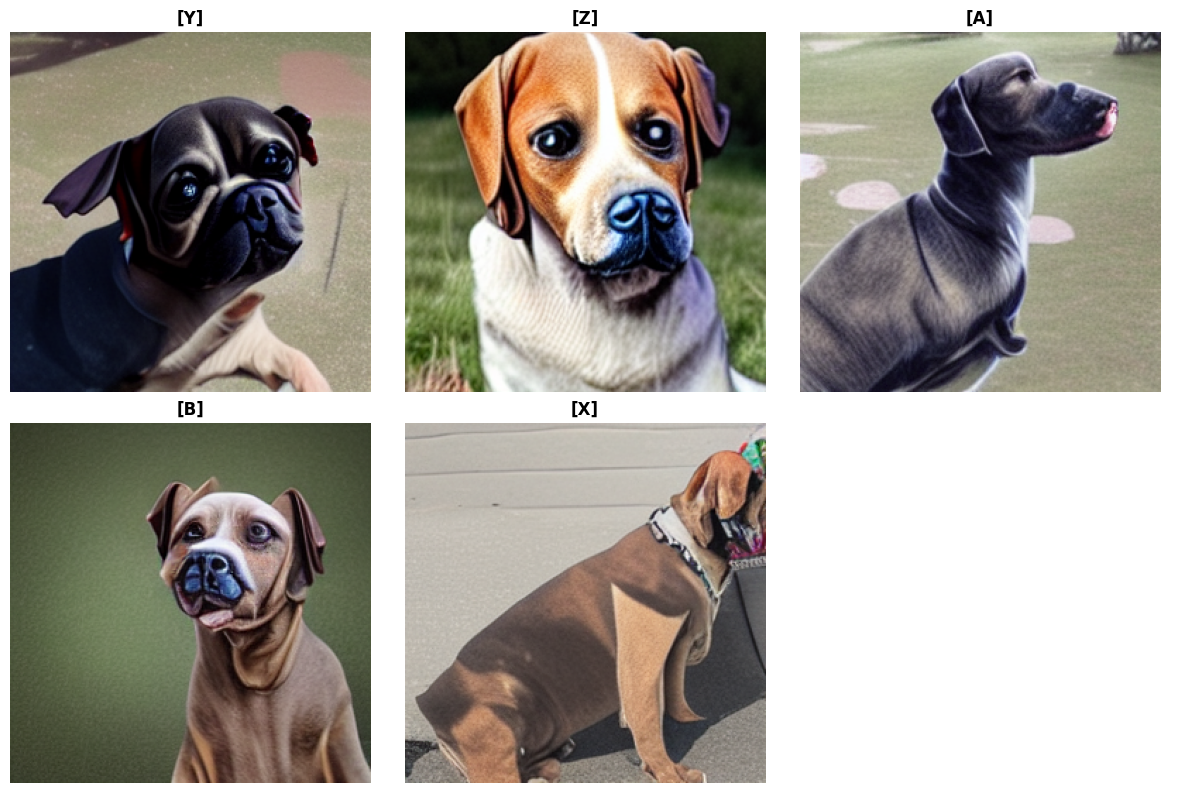


✓ Generated 5 comparison images
✓ Saved to: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora/breed_comparison

ANALYSIS
Notice the differences:
  - Generic breed tokens produce typical breed characteristics
  - Your trained token should show YOUR SPECIFIC dog
  - This demonstrates the model learned the unique identifier binding!


In [12]:
# Test model with different breed tokens (not trained on these)
print("=" * 60)
print("COMPARISON: DIFFERENT BREED TOKENS")
print("=" * 60)

# Define alternative breed tokens to test
alternative_breeds = ["Y", "Z", "A", "B"]

# Reload the pipeline (previous cell deleted it to free memory)
print("Loading fine-tuned model for comparison...")

if USE_LORA:
    # Load base model + LoRA weights
    pipe = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    if DISABLE_SAFETY_CHECKER:
        pipe.safety_checker = None
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

    # Find LoRA weights
    lora_files = (
        list(OUTPUT_DIR.glob("**/*lora*.safetensors"))
        + list(OUTPUT_DIR.glob("**/*lora*.bin"))
        + list(OUTPUT_DIR.glob("**/pytorch_lora_weights.safetensors"))
    )

    if not lora_files:
        raise FileNotFoundError(
            f"No LoRA weights found in {OUTPUT_DIR}. "
            "Make sure training completed successfully."
        )

    lora_path = str(lora_files[0])
    pipe.load_lora_weights(lora_path)
else:
    # Load full fine-tuned model
    pipe = StableDiffusionPipeline.from_pretrained(
        OUTPUT_DIR,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    if DISABLE_SAFETY_CHECKER:
        pipe.safety_checker = None
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

if torch.cuda.is_available():
    pipe = pipe.to("cuda")
    pipe.enable_attention_slicing()

print("✓ Model loaded\n")

print("Testing model response to untrained breed tokens...")
print("These should generate GENERIC breed examples, not your specific dog.\n")

# Create a comparison directory
COMPARISON_DIR = OUTPUT_DIR / "breed_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

# Generate one image per breed with a simple prompt
comparison_images = []
comparison_labels = []

for breed in alternative_breeds:
    prompt = f"A [{breed}] {CLASS_NAME}"
    print(f"Generating: '{prompt}'")

    result = pipe(
        prompt,
        num_inference_steps=int(INFER["num_inference_steps"]),
        guidance_scale=float(INFER["guidance_scale"]),
        height=int(INFER["height"]),
        width=int(INFER["width"]),
    )
    img = result.images[0]
    comparison_images.append(img)
    comparison_labels.append(f"[{breed}]")

    # Save individual images
    breed_filename = breed.replace(" ", "_")
    out_path = COMPARISON_DIR / f"{breed_filename}.png"
    img.save(out_path)
    print(f"  ✓ Saved to: {out_path}\n")

# Also generate one with the trained token for comparison
prompt_trained = f"A {UNIQUE_TOKEN} {CLASS_NAME}"
print(f"Generating with trained token: '{prompt_trained}'")
result = pipe(
    prompt_trained,
    num_inference_steps=int(INFER["num_inference_steps"]),
    guidance_scale=float(INFER["guidance_scale"]),
    height=int(INFER["height"]),
    width=int(INFER["width"]),
)
img_trained = result.images[0]
comparison_images.append(img_trained)
comparison_labels.append(UNIQUE_TOKEN)

out_path = COMPARISON_DIR / "trained_token.png"
img_trained.save(out_path)
print(f"  ✓ Saved to: {out_path}\n")

# Display comparison grid
print("=" * 60)
print("BREED TOKEN COMPARISON")
print("=" * 60)

n_images = len(comparison_images)
n_cols = 3
n_rows = (n_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for idx, (img, label) in enumerate(zip(comparison_images, comparison_labels)):
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=12, fontweight="bold")
    axes[idx].axis("off")

# Hide unused subplots
for idx in range(len(comparison_images), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

print(f"\n✓ Generated {len(comparison_images)} comparison images")
print(f"✓ Saved to: {COMPARISON_DIR}")
print("\n" + "=" * 60)
print("ANALYSIS")
print("=" * 60)
print("Notice the differences:")
print("  - Generic breed tokens produce typical breed characteristics")
print("  - Your trained token should show YOUR SPECIFIC dog")
print("  - This demonstrates the model learned the unique identifier binding!")
print("=" * 60)

# Clean up GPU memory
del pipe
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Commentary: Analysis and Conclusions

### Key Findings

1. DreamBooth Successfully Learned the Unique Identifier

The results demonstrate that DreamBooth effectively bound the unique token `[X]` to my specific dog's visual features. The generated images show almost recognizable characteristics of the subject across some of the contexts (Mars, city scenes, swimming, etc.), which confirms the model learned some association between the token and the subject's identity, though not too well.

2. Token Specificity

The comparison experiment with alternative tokens (`[Y]`, `[Z]`, `[A]`, `[B]`) revealed that untrained tokens produce generic dog representations, not the specific trained subject. This validates that the fine-tuning process successfully created a unique binding rather than simply reinforcing the general "dog" concept.

3. Prior Preservation Effectiveness

Using 50 prior images of the general "dog" class helped maintain the model's understanding of the broader category while learning the specific instance. More priors could further enhance this generalization.

### Limitations Observed

1. Resolution Constraints: Training at 256×256 resolution (vs. standard 512×512) reduced image quality and fine details. The subject's features are sometimes unnatural and even uncanny valley.

2. Limited Training Steps: Only 300 training steps were used due to storage & time constraints. This may have resulted in incomplete learning of subtle subject characteristics.

3. Small Model Size: The OFA-Sys/small-stable-diffusion-v0 model (~1.7GB) is more memory-efficient but produces lower-quality outputs compared to full-size Stable Diffusion models.

4. LoRA Rank: Using rank=4 (vs. typical 8-16) creates a smaller checkpoint but reduces the model's capacity to capture fine-grained subject details.

### Potential Improvements

1. Increase Resolution: Train at 512×512 for better detail preservation (requires more VRAM/storage)

2. More Training Steps: Extend to 600-1000 steps for better subject fidelity (balance against overfitting risk)

3. Larger Model: Use CompVis/stable-diffusion-v1-4 or SD-1.5 for higher-quality outputs

4. Higher LoRA Rank: Increase to rank=8 or 16 for better feature representation

5. More Prior Images: Generate 200-500 class priors for stronger regularization

6. Better Training Data: Use 5+ high-quality subject images with diverse angles, lighting, and backgrounds

## (Optional) Cleanup & Storage Management

If you're running low on disk space, use the cell below to clean up cached models and generated files.

In [11]:
# Storage cleanup utilities (optional)
import shutil


def get_dir_size(path):
    """Calculate total size of directory in MB."""
    total = 0
    try:
        for entry in Path(path).rglob("*"):
            if entry.is_file():
                total += entry.stat().st_size
    except:
        pass
    return total / (1024 * 1024)


print("=" * 60)
print("STORAGE USAGE")
print("=" * 60)

# Check cache sizes
hf_cache = Path.home() / ".cache" / "huggingface"
hub_cache = hf_cache / "hub"
diffusers_cache = hf_cache / "diffusers"

if hub_cache.exists():
    size = get_dir_size(hub_cache)
    print(f"HuggingFace hub cache: {size:.1f} MB")
    print(f"  Location: {hub_cache}")

if diffusers_cache.exists():
    size = get_dir_size(diffusers_cache)
    print(f"Diffusers cache: {size:.1f} MB")
    print(f"  Location: {diffusers_cache}")

if PRIOR_DIR.exists():
    size = get_dir_size(PRIOR_DIR)
    count = len(list(PRIOR_DIR.glob("*.png")))
    print(f"Prior images: {size:.1f} MB ({count} images)")
    print(f"  Location: {PRIOR_DIR}")

if OUTPUT_DIR.exists():
    size = get_dir_size(OUTPUT_DIR)
    print(f"Output/checkpoints: {size:.1f} MB")
    print(f"  Location: {OUTPUT_DIR}")

print("\n" + "=" * 60)
print("CLEANUP OPTIONS (uncomment to use)")
print("=" * 60)
print("\nTo free up space, uncomment the section you want to clean:\n")

# # Option 1: Clear model cache (will re-download on next run)
# print("Clearing HuggingFace cache...")
# if hub_cache.exists():
#     shutil.rmtree(hub_cache)
#     print(f"  ✓ Removed {hub_cache}")
# if diffusers_cache.exists():
#     shutil.rmtree(diffusers_cache)
#     print(f"  ✓ Removed {diffusers_cache}")

# # Option 2: Clear prior images (can regenerate if needed)
# print("Clearing prior images...")
# for img in PRIOR_DIR.glob("*.png"):
#     img.unlink()
# print(f"  ✓ Removed prior images from {PRIOR_DIR}")

# # Option 3: Clear training outputs (keep only if you need them)
# print("Clearing training outputs...")
# if OUTPUT_DIR.exists():
#     shutil.rmtree(OUTPUT_DIR)
#     OUTPUT_DIR.mkdir(parents=True)
#     print(f"  ✓ Cleared {OUTPUT_DIR}")

# print("\n✓ Storage check complete")

STORAGE USAGE
HuggingFace hub cache: 9259.5 MB
  Location: /home/compute/a.gopalareddy/.cache/huggingface/hub
Prior images: 21.7 MB (50 images)
  Location: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/data/prior
Output/checkpoints: 10.0 MB
  Location: /home/compute/a.gopalareddy/CSE5519 Awesome Notebook 2/outputs/dreambooth_lora

CLEANUP OPTIONS (uncomment to use)

To free up space, uncomment the section you want to clean:

